###  Ejercicio 10 de Septiembre

Construyamos un árbol de decisión para Wine y para Iris

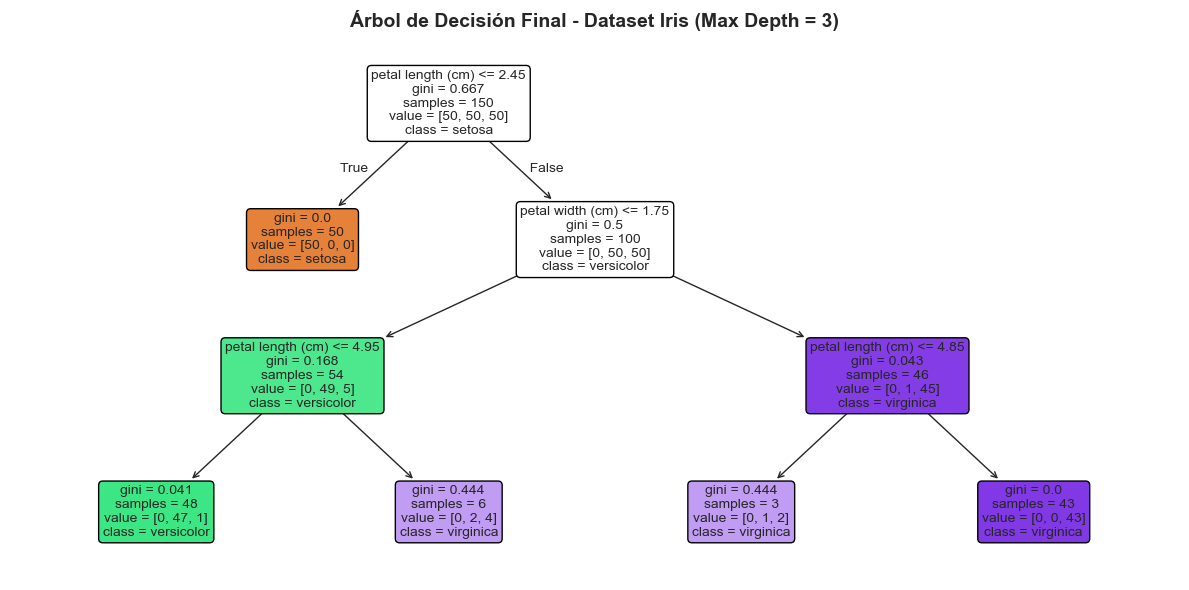

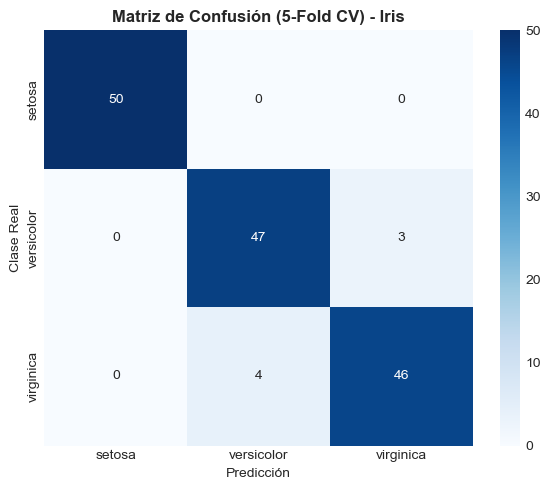

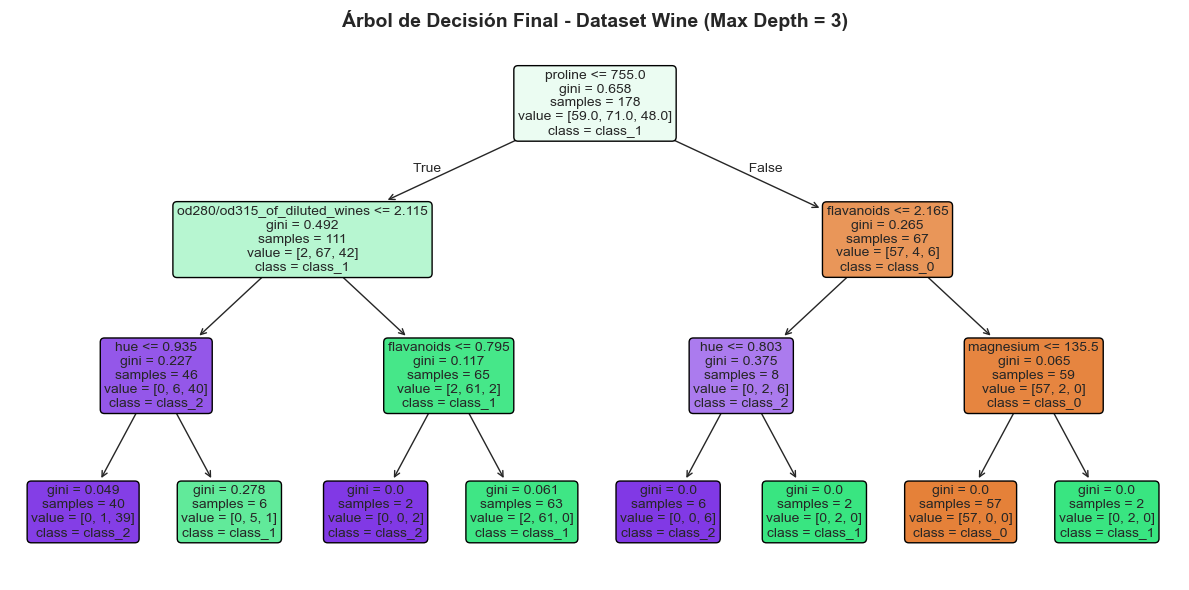

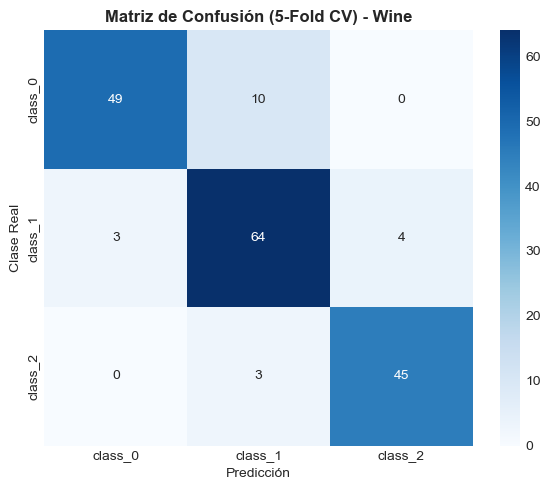

Dataset    | Accuracy   | Precision  | Recall     | F1-Score  
----------------------------------------------------------
Iris       | 0.9533     | 0.9578     | 0.9533     | 0.9533
Wine       | 0.8876     | 0.8914     | 0.8876     | 0.8855


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Configuration general
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

datasets = {
    "Iris": load_iris(),
    "Wine": load_wine()
}

metrics_summary = {}

for name, ds in datasets.items():
    X, y = ds.data, ds.target
    feature_names = ds.feature_names
    target_names = ds.target_names
    
    # Modelo: Arbol de decision con profundidad controlada para evitar sobreajuste
    clf = DecisionTreeClassifier(max_depth=3, random_state=42)
    
    # 1. Evaluacion mediante K-Fold Cross Validation
    scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
    cv_results = cross_validate(clf, X, y, cv=kf, scoring=scoring)
    
    metrics_summary[name] = {
        'Accuracy': np.mean(cv_results['test_accuracy']),
        'Precision': np.mean(cv_results['test_precision_weighted']),
        'Recall': np.mean(cv_results['test_recall_weighted']),
        'F1-Score': np.mean(cv_results['test_f1_weighted'])
    }
    
    # 2. Matriz de confusion mediante predicciones en Cross-Validation
    y_pred_cv = cross_val_predict(clf, X, y, cv=kf)
    cm = confusion_matrix(y, y_pred_cv)
    
    # 3. Entrenamiento final para visualizacion de estructura
    clf.fit(X, y)
    
    # Grafico 1: Estructura del Arbol
    plt.figure(figsize=(12, 6))
    plot_tree(
        clf, 
        feature_names=feature_names, 
        class_names=target_names, 
        filled=True, 
        rounded=True, 
        fontsize=10
    )
    plt.title(f"Árbol de Decisión Final - Dataset {name} (Max Depth = 3)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Grafico 2: Matriz de Confusion (Acumulada en CV)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f"Matriz de Confusión ({k_folds}-Fold CV) - {name}", fontsize=12, fontweight='bold')
    plt.xlabel("Predicción")
    plt.ylabel("Clase Real")
    plt.tight_layout()
    plt.show()

# Print de resumen de metricas
print(f"{'Dataset':<10} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 58)
for name, m in metrics_summary.items():
    print(f"{name:<10} | {m['Accuracy']:.4f}     | {m['Precision']:.4f}     | {m['Recall']:.4f}     | {m['F1-Score']:.4f}")

Regresión lineal con 100 datos aleatorios (foto de la regresión en la carpeta (linear_regression.png))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configurar semilla para reproducibilidad
np.random.seed(42)

# 1. Generar 100 puntos (x, y) con ruido gaussiano
x = np.random.uniform(0, 10, 100).reshape(-1, 1)
# Modelo real: y = 2.5 * x + 5 + ruido
noise = np.random.normal(0, 2.5, size=(100, 1))
y = 2.5 * x + 5 + noise

# 2. Entrenar la regresión lineal
model = LinearRegression()
model.fit(x, y)

# Predicciones
y_pred = model.predict(x)

# Métricas
slope = model.coef_[0][0]
intercept = model.intercept_[0]
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"Pendiente (m): {slope:.4f}")
print(f"Intersección (b): {intercept:.4f}")
print(f"R^2: {r2:.4f}")
print(f"MSE: {mse:.4f}")

# Visualización
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', alpha=0.6, label='Puntos con ruido (Datos)')
plt.plot(x, y_pred, color='red', linewidth=2, label=f'Línea de regresión: y = {slope:.2f}x + {intercept:.2f}')
plt.title('Regresión Lineal Simple con 100 Puntos Aleatorios')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('linear_regression.png')
plt.close()



Pendiente (m): 2.3851
Intersección (b): 5.5377
R^2: 0.9081
MSE: 5.0412


Crear una ANN con función deactivación simple para generar una linea de regresión para los datos construidos en el literal anterior

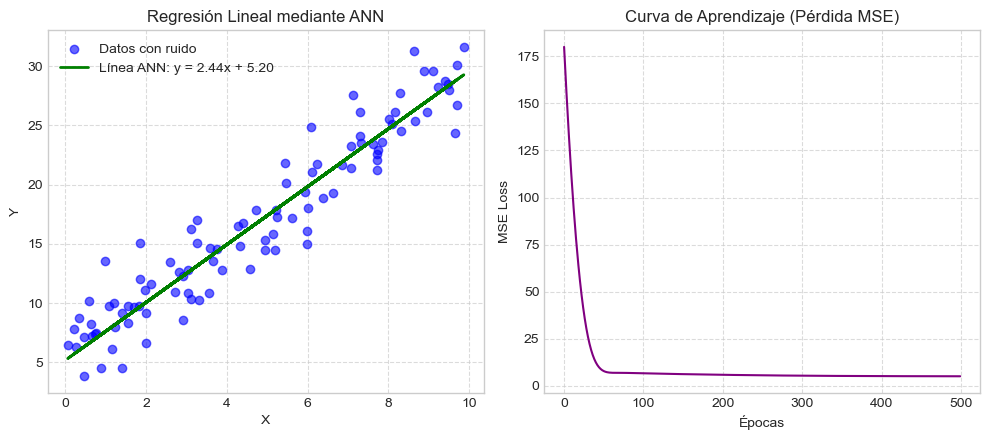

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Regeneración de los datos anteriores (semilla 42)
np.random.seed(42)
torch.manual_seed(42)

x_np = np.random.uniform(0, 10, 100).reshape(-1, 1)
noise = np.random.normal(0, 2.5, size=(100, 1))
y_np = 2.5 * x_np + 5 + noise

X = torch.tensor(x_np, dtype=torch.float32)
Y = torch.tensor(y_np, dtype=torch.float32)

# 2. Definición de la Red Neuronal (1 capa, 1 neurona, activación lineal)
class LinearANN(nn.Module):
    def __init__(self):
        super(LinearANN, self).__init__()
        self.linear = nn.Linear(1, 1)  # Entrada 1D -> Salida 1D
        
    def forward(self, x):
        return self.linear(x)  # Activación lineal: f(z) = z

model = LinearANN()

# 3. Función de pérdida y optimizador
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

# 4. Entrenamiento de la ANN (500 épocas)
epochs = 500
losses = []

for epoch in range(epochs):
    predictions = model(X)
    loss = criterion(predictions, Y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())

# Extracción de parámetros aprendidos
w_ann = model.linear.weight.item()
b_ann = model.linear.bias.item()
y_pred_ann = model(X).detach().numpy()

# Visualización
plt.figure(figsize=(10, 4.5))

plt.subplot(1, 2, 1)
plt.scatter(x_np, y_np, color='blue', alpha=0.6, label='Datos con ruido')
plt.plot(x_np, y_pred_ann, color='green', linewidth=2, label=f'Línea ANN: y = {w_ann:.2f}x + {b_ann:.2f}')
plt.title('Regresión Lineal mediante ANN')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(range(epochs), losses, color='purple', linewidth=1.5)
plt.title('Curva de Aprendizaje (Pérdida MSE)')
plt.xlabel('Épocas')
plt.ylabel('MSE Loss')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generación de los 100 puntos con ruido (semilla 42)
np.random.seed(42)
torch.manual_seed(42)

x_all = np.random.uniform(0, 10, 100).reshape(-1, 1)
noise = np.random.normal(0, 2.5, size=(100, 1))
y_all = 2.5 * x_all + 5 + noise

# 2. Partición Train (70%) / Test (30%)
x_train_np, x_test_np, y_train_np, y_test_np = train_test_split(
    x_all, y_all, test_size=0.30, random_state=42
)

# Conversión a tensores de PyTorch
X_train = torch.tensor(x_train_np, dtype=torch.float32)
Y_train = torch.tensor(y_train_np, dtype=torch.float32)
X_test = torch.tensor(x_test_np, dtype=torch.float32)
Y_test = torch.tensor(y_test_np, dtype=torch.float32)

# 3. Definición de Neurona Única: f(x) = w*x + bias
class SingleNeuronRegression(nn.Module):
    def __init__(self):
        super(SingleNeuronRegression, self).__init__()
        self.neuron = nn.Linear(in_features=1, out_features=1, bias=True)
        
    def forward(self, x):
        return self.neuron(x)

model = SingleNeuronRegression()

# 4. Configuración del optimizador e iteración
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

epochs = 500
train_losses, test_losses = [], []

for epoch in range(epochs):
    model.train()
    predictions_train = model(X_train)
    loss_train = criterion(predictions_train, Y_train)
    
    # Optimización iterativa del peso (w) y bias (b) mediante retropropagación
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()
    
    # Evaluación en Test sin actualizar pesos
    model.eval()
    with torch.no_grad():
        predictions_test = model(X_test)
        loss_test = criterion(predictions_test, Y_test)
        
    train_losses.append(loss_train.item())
    test_losses.append(loss_test.item())

# Métricas finales
w_learned = model.neuron.weight.item()
b_learned = model.neuron.bias.item()

w_learned, b_learned


(2.4421701431274414, 4.9374823570251465)

Se usó en este caso scikit learn y pytorch
Se usó una única neurona
la función de costo es el error cuadrático medio
El bias en la regresión simple (lineal) se usa para desplazar la linea verticalmente. Ayuda en la función de costos para que los resultados se ajusten según los valores reales, y no solo la salida de la función de activación
La matemática de la red es muy sencilla, esta contiene una función de activación lineal, es decir no hay cambio al modelo lineal original. Es decir, el peso $w$ de la neurona sería n las derivadas parciales de la función lineal, los coeficientes del hiperplano. 

Ahora, hagamos el uso de Keras, una API usada sobre tensorflow parai mplmeentar modelos de aprendizaje profundo, como redes neuronales.

 

c:\Users\jtjua\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Train MSE: 5.6917 | Train R^2: 0.8848
Test MSE: 4.4091 | Test R^2: 0.9343
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


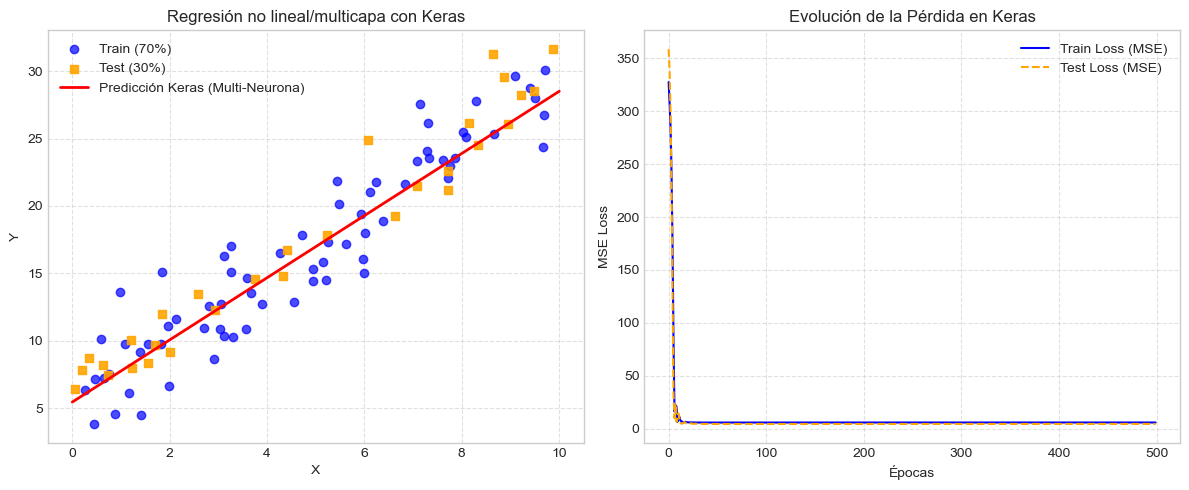

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Regeneración de los 100 datos sintéticos (semilla 42)
np.random.seed(42)
tf.random.set_seed(42)

x_all = np.random.uniform(0, 10, 100).reshape(-1, 1)
noise = np.random.normal(0, 2.5, size=(100, 1))
y_all = 2.5 * x_all + 5 + noise

# 2. División Train (70%) / Test (30%)
x_train, x_test, y_train, y_test = train_test_split(
    x_all, y_all, test_size=0.30, random_state=42
)

# 3. Construcción del modelo Multicapa (ANN con varias neuronas)
model = Sequential([
    Dense(16, activation='relu', input_shape=(1,)), # Capa oculta 1: 16 neuronas + ReLU
    Dense(8, activation='relu'),                  # Capa oculta 2: 8 neuronas + ReLU
    Dense(1, activation='linear')                 # Capa de salida: 1 neurona (Regresión)
])

# 4. Compilación del modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.03),
    loss='mean_squared_error'
)

# 5. Entrenamiento iterativo (500 épocas)
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=500,
    batch_size=16,
    verbose=0
)

# 6. Evaluación y predicciones
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Train MSE: {mse_train:.4f} | Train R^2: {r2_train:.4f}")
print(f"Test MSE: {mse_test:.4f} | Test R^2: {r2_test:.4f}")

# 7. Visualización de resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Predicción de la ANN frente a datos reales
x_line = np.linspace(0, 10, 100).reshape(-1, 1)
y_line = model.predict(x_line)

axes[0].scatter(x_train, y_train, color='blue', alpha=0.7, label='Train (70%)')
axes[0].scatter(x_test, y_test, color='orange', alpha=0.9, marker='s', label='Test (30%)')
axes[0].plot(x_line, y_line, color='red', linewidth=2, label='Predicción Keras (Multi-Neurona)')
axes[0].set_title('Regresión no lineal/multicapa con Keras')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Curva de Pérdida (MSE Train vs Test)
axes[1].plot(history.history['loss'], label='Train Loss (MSE)', color='blue', linewidth=1.5)
axes[1].plot(history.history['val_loss'], label='Test Loss (MSE)', color='orange', linestyle='--', linewidth=1.5)
axes[1].set_title('Evolución de la Pérdida en Keras')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 29s 2us/step


c:\Users\jtjua\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8989 - loss: 0.3449 - val_accuracy: 0.9655 - val_loss: 0.1196
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9531 - loss: 0.1524 - val_accuracy: 0.9723 - val_loss: 0.0947
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9649 - loss: 0.1141 - val_accuracy: 0.9765 - val_loss: 0.0790
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9699 - loss: 0.0944 - val_accuracy: 0.9777 - val_loss: 0.0811
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9735 - loss: 0.0834 - val_accuracy: 0.9788 - val_loss: 0.0735
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9779 - loss: 0.0706 - val_accuracy: 0.9797 - val_loss: 0.0702
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9802 - loss: 0.0620 - val_accuracy: 0.9793 - val_loss: 0.0734
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9811 - loss: 0.0568 - val_accuracy: 0.

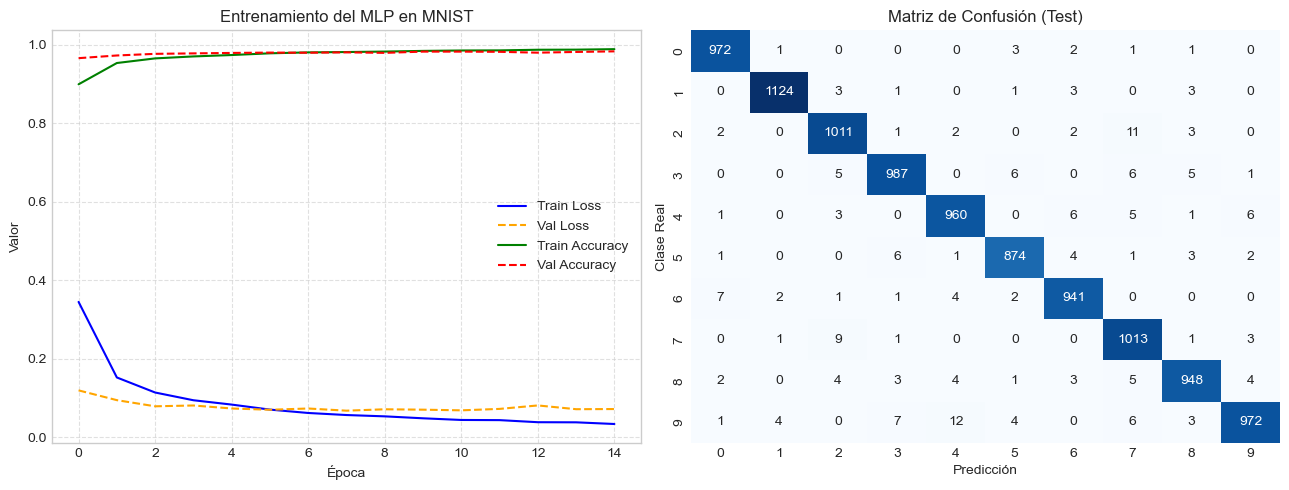

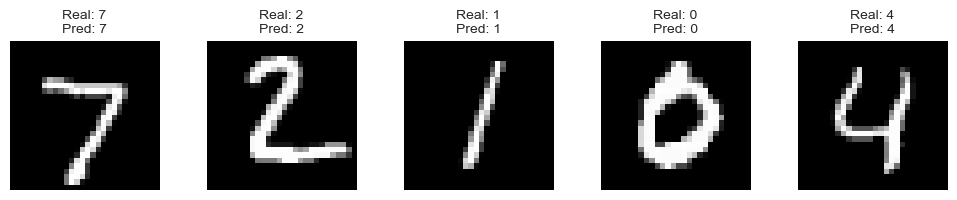

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from sklearn.metrics import confusion_matrix, classification_report

# 1. Cargar el dataset MNIST
(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

# 2. Normalizar los valores de los píxeles [0, 255] -> [0, 1]
X_train = X_train_raw / 255.0
X_test = X_test_raw / 255.0

# 3. Definir la arquitectura del MLP
model = Sequential([
    Flatten(input_shape=(28, 28)),          # Aplana matriz 28x28 a vector de 784
    Dense(128, activation='relu'),          # Capa oculta 1: 128 neuronas
    Dropout(0.2),                           # Regularización para evitar sobreajuste
    Dense(64, activation='relu'),           # Capa oculta 2: 64 neuronas
    Dense(10, activation='softmax')         # Capa de salida: 10 clases (dígitos 0-9)
])

# 4. Compilar el modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Entrenar el MLP
history = model.fit(
    X_train, y_train,
    validation_split=0.1,                   # 10% de train para validación
    epochs=15,
    batch_size=64,
    verbose=1
)

# 6. Evaluación en el conjunto de prueba (Test)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nExactitud en Test (Accuracy): {test_acc * 100:.2f}%")
print(f"Pérdida en Test (Loss): {test_loss:.4f}")

# 7. Generar predicciones y matriz de confusión
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

# 8. Visualización de Resultados
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Curvas de Pérdida y Accuracy
axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange', linestyle='--')
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='green')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='red', linestyle='--')
axes[0].set_title('Entrenamiento del MLP en MNIST')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Valor')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Matriz de Confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Matriz de Confusión (Test)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Clase Real')

plt.tight_layout()
plt.show()

# Visualizar 5 ejemplos con sus predicciones
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Real: {y_test[i]}\nPred: {y_pred[i]}", fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
import sys
print("Ruta del ejecutable de Python actual:")
print(sys.executable)

try:
    import tensorflow as tf
    print("\n¡TensorFlow cargado con éxito! Versión:", tf.__version__)
except ModuleNotFoundError:
    print("\nTensorFlow NO está instalado en esta ruta de Python.")

Ruta del ejecutable de Python actual:
c:\Users\jtjua\anaconda3\python.exe

¡TensorFlow cargado con éxito! Versión: 2.21.0
